In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score,recall_score,f1_score
import xgboost as xgb


#### *****Hypothesis: Heart failure severity, other illnesses, kidney function, vital signs, and length of stay may contain information that helps predict a return to the ED within six months.*****

In [21]:
# Read merged file
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")
# Creating a copy of the data to work on, so the original data is not modified
df = hf_df.copy()

In [22]:
# Choose the inout columns 
features = [
    "cci_score",                             # Other illnesses
    "nyha_cardiac_function_classification", # Heart failure symptoms
    "killip_grade",                          # Illness severity
    "gfr",                                   # Kidney function
    "bnp",                                   # Heart failure-related measurement
    "pulse",                                 # Vital sign
    "respiration",                           # Vital sign
    "systolic_bp",                            # Vital sign
    "discharge_day"                          # Days in hospital
]
target = "ed_return_6mo"

In [23]:
# Prepare the data
work = hf_df[["patient_id", target] + features].copy()

for col in features + [target]:
    work[col] = pd.to_numeric(work[col], errors="coerce")

# We can train only where the actual ED outcome is known
work = work[work[target].isin([0, 1])].copy()

X = work[features]       # Information used to predict
y = work[target].astype(int)  # Actual answer

print("Records used:", len(work))
print("ED returns:", y.sum())
print("ED return rate:", round(y.mean() * 100, 1), "%")
print("\nMissing input values:\n", X.isna().sum())

Records used: 2007
ED returns: 775
ED return rate: 38.6 %

Missing input values:
 cci_score                                5
nyha_cardiac_function_classification     0
killip_grade                             0
gfr                                     63
bnp                                     35
pulse                                    1
respiration                              1
systolic_bp                              5
discharge_day                            0
dtype: int64


In [24]:
# Keep some patients aside for testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training records:", len(X_train))
print("Test records:", len(X_test))

Training records: 1605
Test records: 402


In [25]:
# Train the random forest
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

model = make_pipeline(
    SimpleImputer(strategy="median"),
    RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=10,
        random_state=42
    )
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['cci_score','nyha_cardiac_function_classification','killip_grade',..., 'respiration','systolic_bp','discharge_day']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to r

In [26]:
# Get predictions for the test patients
probability = model.predict_proba(X_test)[:, 1]
predicted = model.predict(X_test)

results = pd.DataFrame({
    "actual_ed_return": y_test.to_numpy(),
    "predicted_probability": probability,
    "predicted_class": predicted
})

display(results.head(10))

,actual_ed_return,predicted_probability,predicted_class
0,1,0.497945,0
1,1,0.410172,0
2,1,0.457560,0
3,0,0.255472,0
4,0,0.313959,0
5,1,0.576575,1
6,0,0.475306,0
7,1,0.270014,0
8,1,0.312171,0
9,0,0.455483,0


Test ED return rate: 0.386
ROC-AUC: 0.615
Average precision: 0.486

              precision    recall  f1-score   support

           0       0.64      0.90      0.75       247
           1       0.56      0.19      0.29       155

    accuracy                           0.63       402
   macro avg       0.60      0.55      0.52       402
weighted avg       0.61      0.63      0.57       402



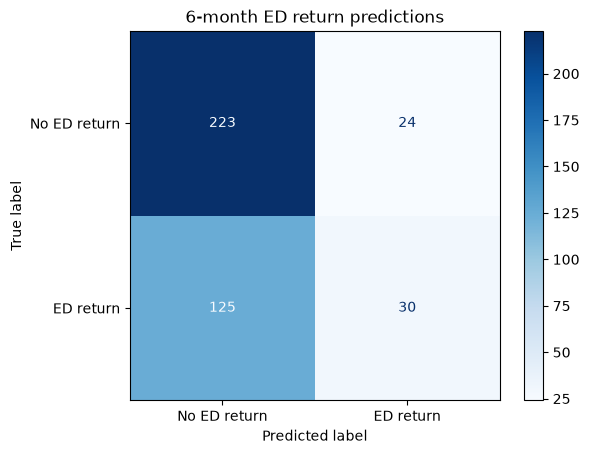

In [27]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print("Test ED return rate:", round(y_test.mean(), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, probability), 3))
print("Average precision:",
      round(average_precision_score(y_test, probability), 3))
print()
print(classification_report(y_test, predicted))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicted,
    display_labels=["No ED return", "ED return"],
    cmap="Blues"
)
plt.title("6-month ED return predictions")
plt.show()

In [28]:
print("ROC-AUC:", round(roc_auc_score(y_test, probability), 3))
print("Average precision:",
      round(average_precision_score(y_test, probability), 3))

ROC-AUC: 0.615
Average precision: 0.486


#### ***The random forest showed modest ability to rank patients by six-month ED return risk (ROC-AUC 0.615; average precision 0.486 versus a 0.386 test-set return rate). At the default classification cutoff, it identified only 30 of 155 patients who returned (19% recall). Therefore, this model provides some evidence of a predictive relationship, but its current performance does not support using it to reliably identify patients for follow-up review.”***